# Principal Component Analysis (PCA)


PCA (Principal Component Analysis) is a dimensionality reduction technique and helps us to reduce the number of features in a dataset while keeping the most important information.

#How Principal Component Analysis Works

# Step 1: Standardize the Data

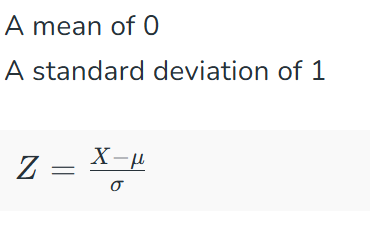

# Step 2: Calculate Covariance Matrix


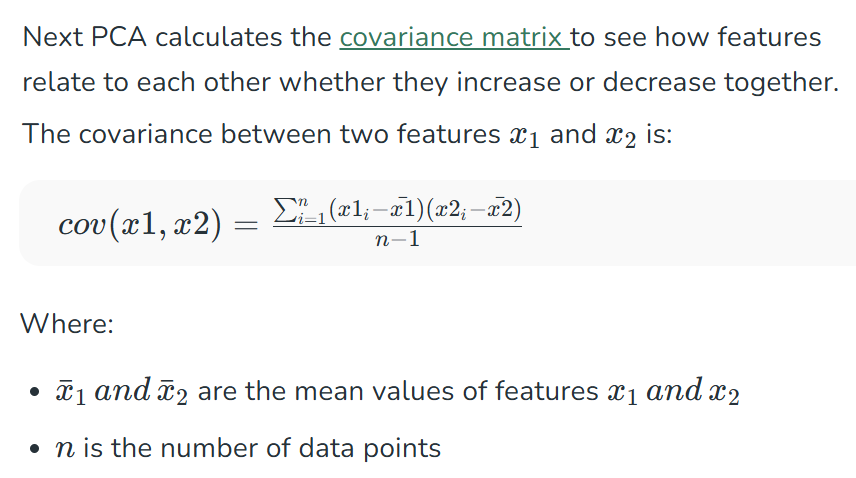

# Step 3: Find the Principal Components

PCA identifies new axes where the data spreads out the most:

1st Principal Component (PC1): The direction of maximum variance (most spread).
2nd Principal Component (PC2): The next best direction, perpendicular to PC1 and so on.

# Step 4: Pick the Top Directions & Transform Data


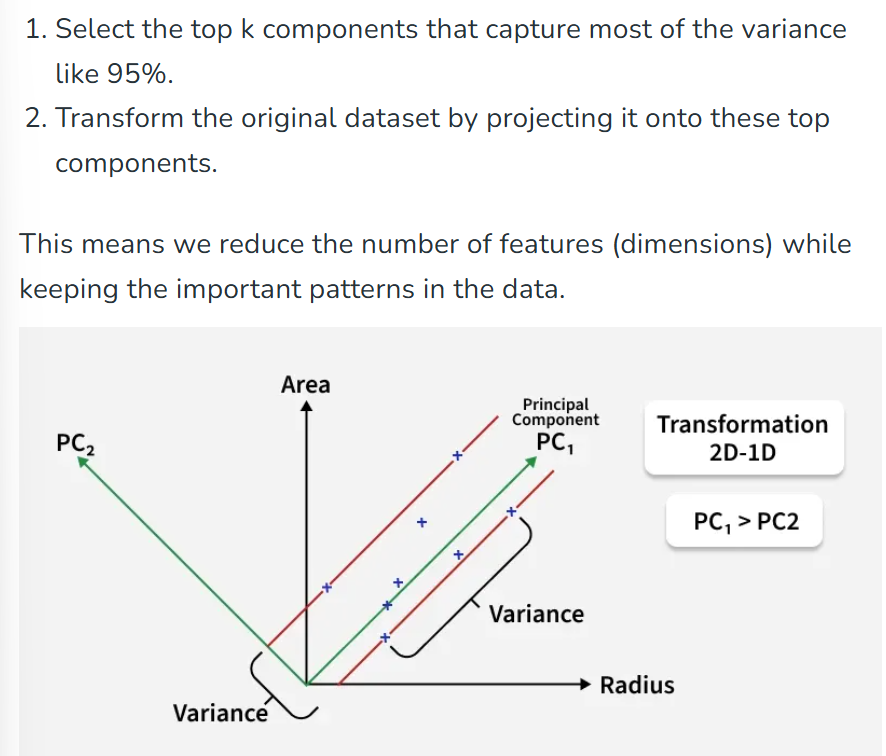

# coding implementation

In [18]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
import seaborn as sns
import matplotlib. pyplot as plt



In [19]:
data = {
    'Height': [170, 165, 180, 175, 160, 172, 168, 177, 162, 158],
    'Weight': [65, 59, 75, 68, 55, 70, 62, 74, 58, 54],
    'Age': [30, 25, 35, 28, 22, 32, 27, 33, 24, 21],
    'Gender': [1, 0, 1, 1, 0, 1, 0, 1, 0, 0]  # 1 = Male, 0 = Female
}
df = pd.DataFrame(data)
print(df)

   Height  Weight  Age  Gender
0     170      65   30       1
1     165      59   25       0
2     180      75   35       1
3     175      68   28       1
4     160      55   22       0
5     172      70   32       1
6     168      62   27       0
7     177      74   33       1
8     162      58   24       0
9     158      54   21       0


In [36]:
x=df.drop('Gender',axis=1)
y=df['Gender']

x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [37]:
scaler=StandardScaler()
x_scaled=scaler.fit_transform(x)


In [38]:
pca=PCA(n_components=2)
x_pca=pca.fit_transform(x_scaled)

In [39]:
from sklearn.metrics import confusion_matrix
model=LogisticRegression()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
print(confusion_matrix(y_test,y_pred))



[[1 0]
 [0 1]]


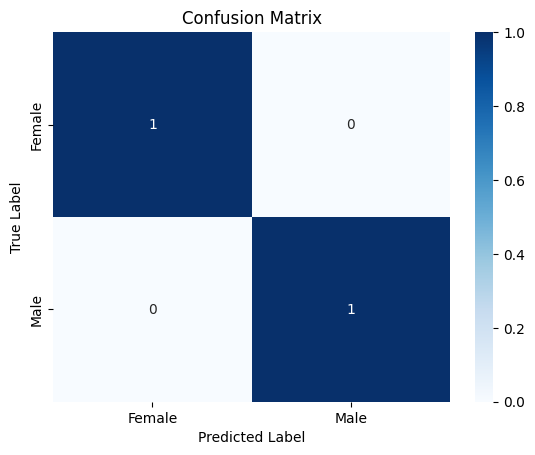

In [40]:
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
sns.heatmap(cm,annot=True, cmap='Blues', xticklabels=['Female', 'Male'], yticklabels=['Female', 'Male'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

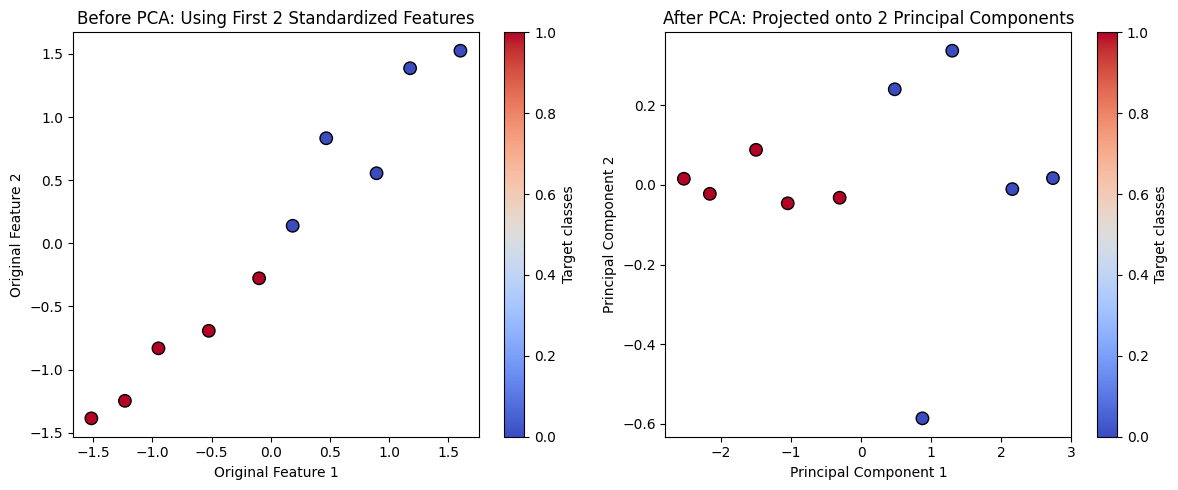

In [41]:
y_numeric = pd.factorize(y)[0]

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(x_scaled[:, 0], x_scaled[:, 1], c=y_numeric, cmap='coolwarm', edgecolor='k', s=80)
plt.xlabel('Original Feature 1')
plt.ylabel('Original Feature 2')
plt.title('Before PCA: Using First 2 Standardized Features')
plt.colorbar(label='Target classes')

plt.subplot(1, 2, 2)
plt.scatter(x_pca[:, 0], x_pca[:, 1], c=y_numeric, cmap='coolwarm', edgecolor='k', s=80)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('After PCA: Projected onto 2 Principal Components')
plt.colorbar(label='Target classes')

plt.tight_layout()
plt.show()